### Initialization

In [1]:
from astropy.cosmology import FlatLambdaCDM
from astropy.units import Quantity
from astropy import units
from collections import Counter
import corner
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# from scipy import stats
# import pandas as pd
# from distfit import distfit
# from matplotlib.ticker import NullFormatter

from slsim.Sources.Events.BNSMerger.bns_merger_pop import BNSMergerRate
from slsim.Sources.Events.BNSMerger.bns_merger_pop import norm_delay_time_distribution

from slsim.Sources.Events.Supernovae.supernovae_pop import SNIaRate
from slsim.Sources.Events.Supernovae.supernovae_pop import calculate_star_formation_rate
from slsim.Sources.Events.Supernovae.supernovae_pop import delay_time_distribution

from slsim.Util.cosmo_util import z_time_interp
from slsim.Sources.Events.event_pop import EventPopulation
from slsim.Sources.Events.event_lightcone import EventLightcone

from slsim.Lenses.LensPopulation.lens_pop import LensPop
from slsim.Lenses.lens import image_separation_from_positions
import slsim.Pipelines as pipelines
from slsim.Deflectors.DeflectorPopulation.galaxy_deflectors import GalaxyDeflectors
from slsim.Sources.SourceCatalogues.BNSCatalog.bns_catalog import BNSCatalog
from slsim.Sources.SourcePopulation.point_sources import PointSources

        Use pytest instead. [astropy.tests.runner]
        Use pytest instead. [astropy.utils.decorators]


In [2]:
def plot(x, y, x_label, y_label, title, color, legend, label):
    plt.plot(x, y, color=color, label=label)
    plt.xlabel(x_label, fontsize=15)
    plt.ylabel(y_label, fontsize=15)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.title(title, fontsize="15")
    if legend:
        plt.legend(fontsize=15)


def semilog(x, y, x_label, y_label, title, color, legend, label):
    plt.semilogy(x, y, color=color, label=label)
    plt.xlabel(x_label, fontsize=15)
    plt.ylabel(y_label, fontsize=15)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.title(title, fontsize="15")
    if legend:
        plt.legend(fontsize=15)


def hist(x, x_label, y_label, title, legend, label, bins, color):
    plt.hist(x, bins=bins, label=label, color=color)
    plt.xlabel(x_label, fontsize=15)
    plt.ylabel(y_label, fontsize=15)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.title(title, fontsize="15")
    if legend:
        plt.legend(fontsize=15)


def scatter(x, y, x_label, y_label, title, legend, label, color):
    plt.scatter(x, y, label=label, color=color, s=10)
    plt.xlabel(x_label, fontsize=15)
    plt.ylabel(y_label, fontsize=15)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.title(title, fontsize="15")
    if legend:
        plt.legend(fontsize=15)

## Event Population Overview

In this overview notebook, we illustrate the implementation of event populations and analyze their distributions, using BNS mergers and Type Ia supernovae as examples.

1. Number density calculation\
    1.1 BNS merger event rate calculation (BNSMergerRate Class)\
    1.2 Type Ia supernova event rate calculation (SNIaRate Class)\
    1.3 Unified event population interface (EventPopulation Class)

2. Lightcone integration (EventLightcone Class)

## Number Density Calculation

### Initialize the BNSMergerRate Class

In [3]:
cosmo = FlatLambdaCDM(70, 0.3)

# Initialize the class
bns_rate = BNSMergerRate(cosmo, 10)

### BNS Merger Plots

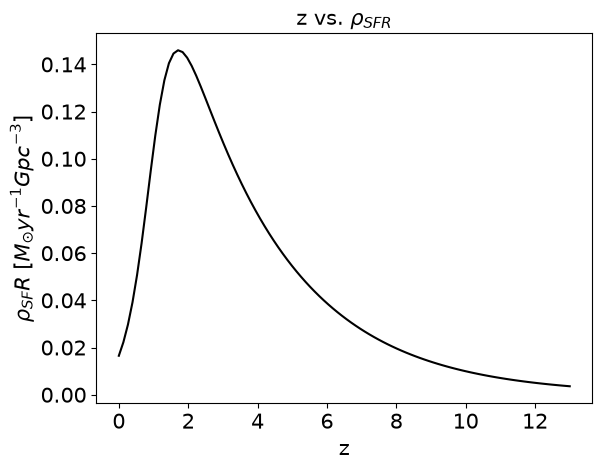

In [4]:
# Define array of redshifts
z_array = np.linspace(0, 13, 100)
rate_list = []

# Calculate binary formation rate given redshift using the function 'calculate_star_formation_rate'
for i in np.arange(100):
    rate_list.append(bns_rate.binary_formation_rate(z_array[i]))

# Plot binary formation rate as a function of redshift
plot(
    z_array,
    rate_list,
    "z",
    r"$\rho_{SF}R$ $[ M_{\odot} yr^{-1}Gpc^{-3}]$",
    "z vs. " r"$\rho_{SFR}$",
    "black",
    False,
    "n/a",
)

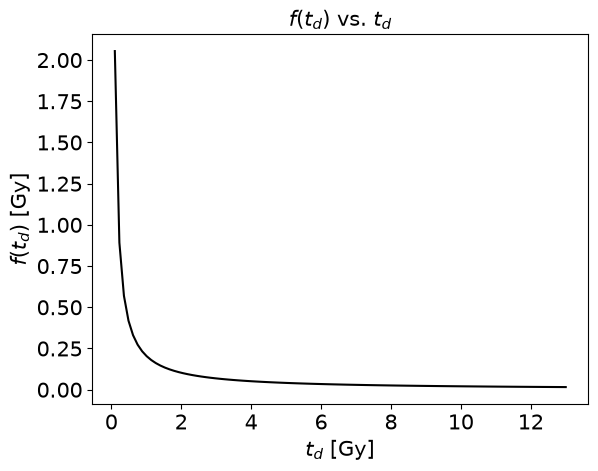

In [5]:
# Define array of time delays
t_d_array = np.linspace(0.1, 13, 100)
dist_list = []

# Calculate time delay distribution given time delay using the function 'norm_delay_time_distribution'
for i in np.arange(100):
    dist_list.append(
        norm_delay_time_distribution(t_d_array[i], min(t_d_array), max(t_d_array))
    )

# Plot time delay distribution as a function of time delay
plot(
    t_d_array,
    dist_list,
    r"$t_{d}$ [Gy]",
    r"$f(t_{d})$ [Gy]",
    "$f(t_{d})$ vs. $t_{d}$",
    "black",
    False,
    "n/a",
)

### Initialize the SNIaRate Class

In [6]:
cosmo = FlatLambdaCDM(70, 0.3)

# Initialize the class
sne_rate = SNIaRate(cosmo, 10)

### SN Ia Plots

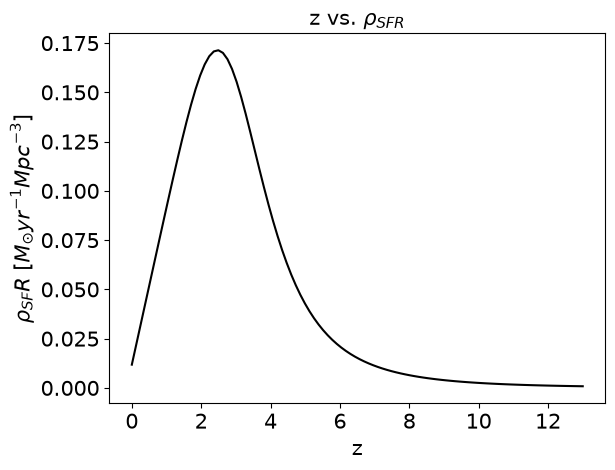

In [7]:
# Define array of redshifts
z_array = np.linspace(0, 13, 100)
rate_list = []

# Calculate star formation rate given redshift using the function 'calculate_star_formation_rate'
for i in np.arange(100):
    rate_list.append(calculate_star_formation_rate(z_array[i]))

# Plot star formation rate as a function of redshift
plot(
    z_array,
    rate_list,
    "z",
    r"$\rho_{SF}R$ $[ M_{\odot} yr^{-1}Mpc^{-3}]$",
    "z vs. " r"$\rho_{SFR}$",
    "black",
    False,
    "n/a",
)

/Users/mia/SLSim/slsim/slsim/Sources/Events/Supernovae/supernovae_pop.py:28: RuntimeWarning: divide by zero encountered in scalar power
  ft_d = (t_d) ** (-1.08)


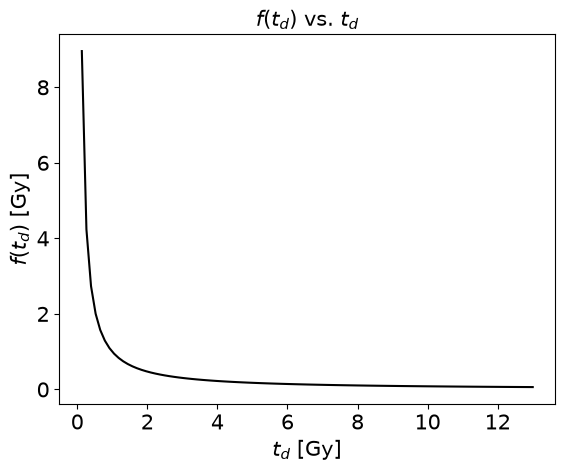

In [8]:
# Define array of time delays
t_d_array = np.linspace(0, 13, 100)
dist_list = []

# Calculate time delay distribution given time delay using the function 'delay_time_distribution'
for i in np.arange(100):
    dist_list.append(delay_time_distribution(t_d_array[i]))

# Plot time delay distribution as a function of time delay
plot(
    t_d_array,
    dist_list,
    r"$t_{d}$ [Gy]",
    r"$f(t_{d})$ [Gy]",
    "$f(t_{d})$ vs. $t_{d}$",
    "black",
    False,
    "n/a",
)

### Initialize the EventPopulation Class

In [9]:
cosmo = FlatLambdaCDM(70, 0.3)

# Initialize the class
event_rate = EventPopulation("BNS", cosmo, 10)

### Plot Redshift As a Function of Time

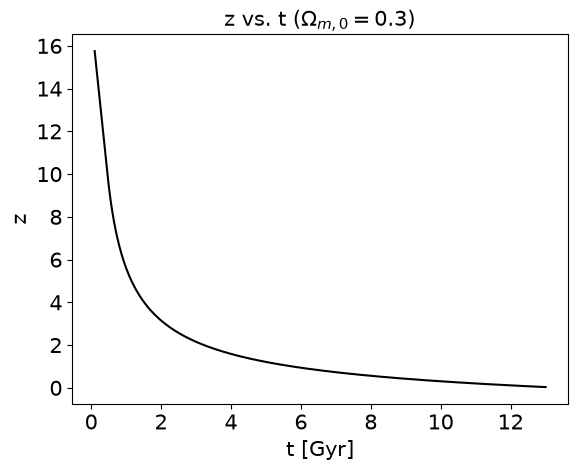

In [10]:
# Define array of times
t_array = np.linspace(0.1, 13, 1000)

# Get the common redshift-time interpolation function.
z_from_time = z_time_interp(cosmo=cosmo, z_max=10)

# Calculate redshift given time
z_list = z_from_time(t_array)

# The same relation can also be accessed through EventPopulation.
# The model keyword can be either "BNS" or "SNIa".
# event_rate = EventPopulation("BNS", cosmo, 10)
# z_list_from_event_pop = event_rate._z_from_time(t_array)

# Plot redshift as a function of time
plot(
    t_array,
    z_list,
    "t [Gyr]",
    "z",
    "z vs. t $(\Omega_{m,0} = 0.3)$",
    "black",
    False,
    r"$H_{0}$=70",
)

### Number Density

/Users/mia/SLSim/slsim/slsim/Sources/Events/BNSMerger/bns_merger_pop.py:102: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  numerator = integrate.quad(
/Users/mia/SLSim/slsim/slsim/Sources/Events/BNSMerger/bns_merger_pop.py:116: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  unorm_BNS_rate_z0 = integrate.quad(


(0.0, 4.0)

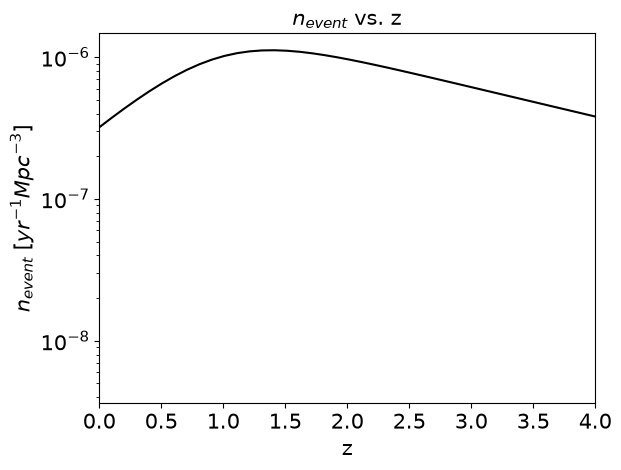

In [11]:
# Define array of redshifts
z_array = np.linspace(0, 10, 100)

# Calculate density given redshift using the class function 'event_rate'
density_list = event_rate.event_rate(z_array)

# Plot number density vs. redshift
semilog(
    z_array,
    density_list,
    "z",
    r"$n_{event}$ $[yr^{-1}Mpc^{-3}]$",
    "$n_{event}$ vs. z",
    "black",
    False,
    r"$H_{0}$=70",
)
plt.xlim(0, 4)
# plt.ylim(10e-6, 10e-4)

## Lightcone Integration

(141,)


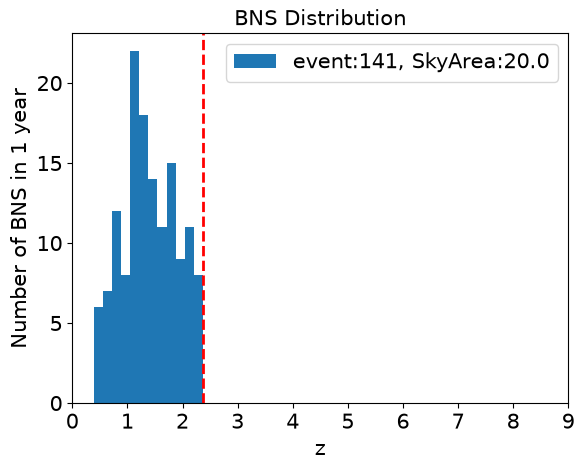

In [12]:
# Define a cosmology
cosmo = FlatLambdaCDM(70, 0.3)

# Define redshift range of the lightcone (at the moment, i-band lightcurve upper limit = 2.379)
redshifts = np.linspace(0, 2.379, 50)

# Define sky area of the lightcone
sky_area = Quantity(value=20, unit="deg2")

# Consider noise in lightcone integration
noise = True

# Choose a model for lightcone calculation
# model = "SNIa"
model = "BNS"

# Define a time interval of the lightcone
time_interval = 1 * units.year

# Initialize lightcone class
event_lightcone = EventLightcone(
    cosmo, redshifts, sky_area, noise, time_interval, model
)

# Generate supernovae catalog within the initialized lightcone using the class function 'supernovae_sample'
lightcone_array = event_lightcone.event_sample()

# Plot histogram of the number of obtained supernovae within the lightcone as a function of redshift
label = "event:{}, SkyArea:{}".format(len(lightcone_array), sky_area.value)
label_y = "Number of " + model + " in 1 year"
caption = model + " Distribution"

hist(
    lightcone_array,
    "z",
    label_y,
    caption,
    True,
    label,
    12,
    None,
)
plt.xlim(0, 9)

# Include i-band lightcurve cutoff line on the plot for clarity
plt.axvline(x=2.379, color="red", linestyle="--", linewidth=2)

print(np.shape(lightcone_array))

## Analyzing the Population

### Generate Lensed Population (Point Source)

In [13]:
# Define a cosmology
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

# Define sky area scaling
sky_area = Quantity(value=10000, unit="deg2")

# Define source and deflector sky areas
source_sky_area = Quantity(value=100, unit="deg2")
deflector_sky_area = Quantity(value=1, unit="deg2")

# Define limits in the intrinsic deflector and source population (in addition to the
# skypy config file)
kwargs_deflector_cut = {"z_min": 0.01, "z_max": 2.379}
kwargs_source_cut = {}

In [14]:
# Generate galaxy population using skypy pipeline which will be used here as deflectors.
galaxy_simulation_pipeline = pipelines.SkyPyPipeline(
    skypy_config=None, sky_area=deflector_sky_area, filters=None, cosmo=cosmo
)

In [15]:
# Initiate deflector population class.
lens_galaxies = GalaxyDeflectors(
    red_galaxy_list=galaxy_simulation_pipeline.red_galaxies,
    blue_galaxy_list=galaxy_simulation_pipeline.blue_galaxies,
    kwargs_cut=kwargs_deflector_cut,  # Cuts to apply to deflector
    kwargs_mass2light=None,
    cosmo=cosmo,
    sky_area=deflector_sky_area,
)

In [16]:
kwargs_kilonova = {
            "mej_1": 0.01, 
            "mej_2": 0.02, 
            "mej_3": 0.03,
            "vej_1": 0.1,
            "vej_2": 0.2, 
            "vej_3": 0.3,
            "kappa_1": 0.5,
            "kappa_2": 3.0,
            "kappa_3": 10.0,
            "temperature_floor_1": 5000,
            "temperature_floor_2": 4000,
            "temperature_floor_3": 3000,
            "kappa_gamma": 10,
        }

In [17]:
# Initiate class that generates BNS merge population
bns_catalog_class = BNSCatalog(
    cosmo=cosmo,
    sky_area=source_sky_area,
    band_list="i",
    lightcurve_time=np.linspace(0.1, 10, 50),
    z_max=5,
    time_interval=1 * units.year,
    noise=True,
    model_name="mosfit_kilonova",
    mag_zpsys="AB",
    modeldir=None,
)
# generate kilonova samples
bns_sample = bns_catalog_class.bns_catalog()

/Users/mia/SLSim/slsim/slsim/Sources/Events/BNSMerger/bns_merger_pop.py:116: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  unorm_BNS_rate_z0 = integrate.quad(


In [18]:
# Initiate source population class
joint_point_source_kwargs= {
    "kwargs_variability": ["bns_lightcurve", "i", "r"],
    "kwargs_kilonova": kwargs_kilonova
}
bns_population = PointSources(
    bns_sample,
    cosmo=cosmo,
    sky_area=source_sky_area,
    kwargs_cut=kwargs_source_cut,  # Cuts to apply to source
    point_source_type="kilonova",
    joint_point_source_kwargs=joint_point_source_kwargs,
)

In [19]:
bns_lens_pop_ps = LensPop(
    deflector_population=lens_galaxies,
    source_population=bns_population,
    sky_area=sky_area,
    cosmo=cosmo,
)

In [20]:
# Print the number of resulting deflectors and sources
bns_lens_pop_ps.deflector_number, bns_lens_pop_ps.source_number

(8516170000, 105100)

In [21]:
# Specify cuts to the population
kwargs_lens_cuts = {}

# Determine the lensed population using 'draw_population'
bns_lens_population_ps = bns_lens_pop_ps.draw_population(
    kwargs_lens_cuts=kwargs_lens_cuts, speed_factor=10000
)

# Print the number of resulting lensed supernovae in the population
len(bns_lens_population_ps)

13:10 redback WARNING : No module named 'lalsimulation'
13:10 redback WARNING : lalsimulation is not installed. Some EOS based models will not work. Please use bilby eos or pass your own EOS generation class to the model
13:10 redback WARNING : swifttools not available. You will not be able to download Swift afterglow data via API.
13:10 bilby INFO    : Running bilby version: 2.8.1
13:10 redback INFO    : Running redback version: 1.18.0


120

### Corner Plot

In [22]:
# Define parameter labels
lens_samples = []
labels = [
    r"$\sigma_v$",
    r"$\log_10(M_{*})$",
    r"$\theta_E$",
    r"$z_{\rm l}$",
    r"$z_{\rm s}$",
    r"$m_{\rm source 0}$",
    r"$m_{\rm source 1}$",
    r"$m_{\rm lens}$",
    r"$t_{\rm max delay}$",
    r"$im_{\rm sep}$",
]

valide_sne_lens_population = []
for ps_lens in bns_lens_population_ps:
    try:
        source_mag = ps_lens.point_source_magnitude(
            band="i", lensed=True
        )[0]
    except ValueError as error:
        if "ps_mag_i is missing" in str(error):
            continue
        raise

    if not np.isnan(source_mag[0]):
        valide_sne_lens_population.append(ps_lens)

In [23]:
# Calculate parameters for each lens
for ps_lens in bns_lens_population_ps:
    vel_disp = ps_lens.deflector_velocity_dispersion()
    m_star = ps_lens.deflector_stellar_mass()
    theta_e = ps_lens.einstein_radius[0]
    zl = ps_lens.deflector_redshift
    zs = ps_lens.source_redshift_list[0]

    source_mag = ps_lens.point_source_magnitude(band="i", lensed=True)[0]
    nan_values = np.isnan(source_mag[0])
    source_mag = np.nan_to_num(source_mag, nan=50)
    source_mag = np.sort(source_mag)

    deflector_mag = ps_lens.deflector_magnitude(band="i")

    time_delay = ps_lens.point_source_arrival_times()[0]
    relative_time_delays = time_delay[1:] - time_delay[0]  # added
    max_time_delay = np.max(time_delay) - np.min(time_delay)

    magnification = ps_lens.point_source_magnification()
    image_sep = image_separation_from_positions(
        ps_lens.point_source_image_positions()[0]
    )
    if not nan_values:
        lens_samples.append(
            [
                vel_disp,
                np.log10(m_star),
                theta_e,
                zl,
                zs,
                source_mag[0],
                source_mag[1],
                deflector_mag,
                max_time_delay,
                image_sep,
            ]
        )


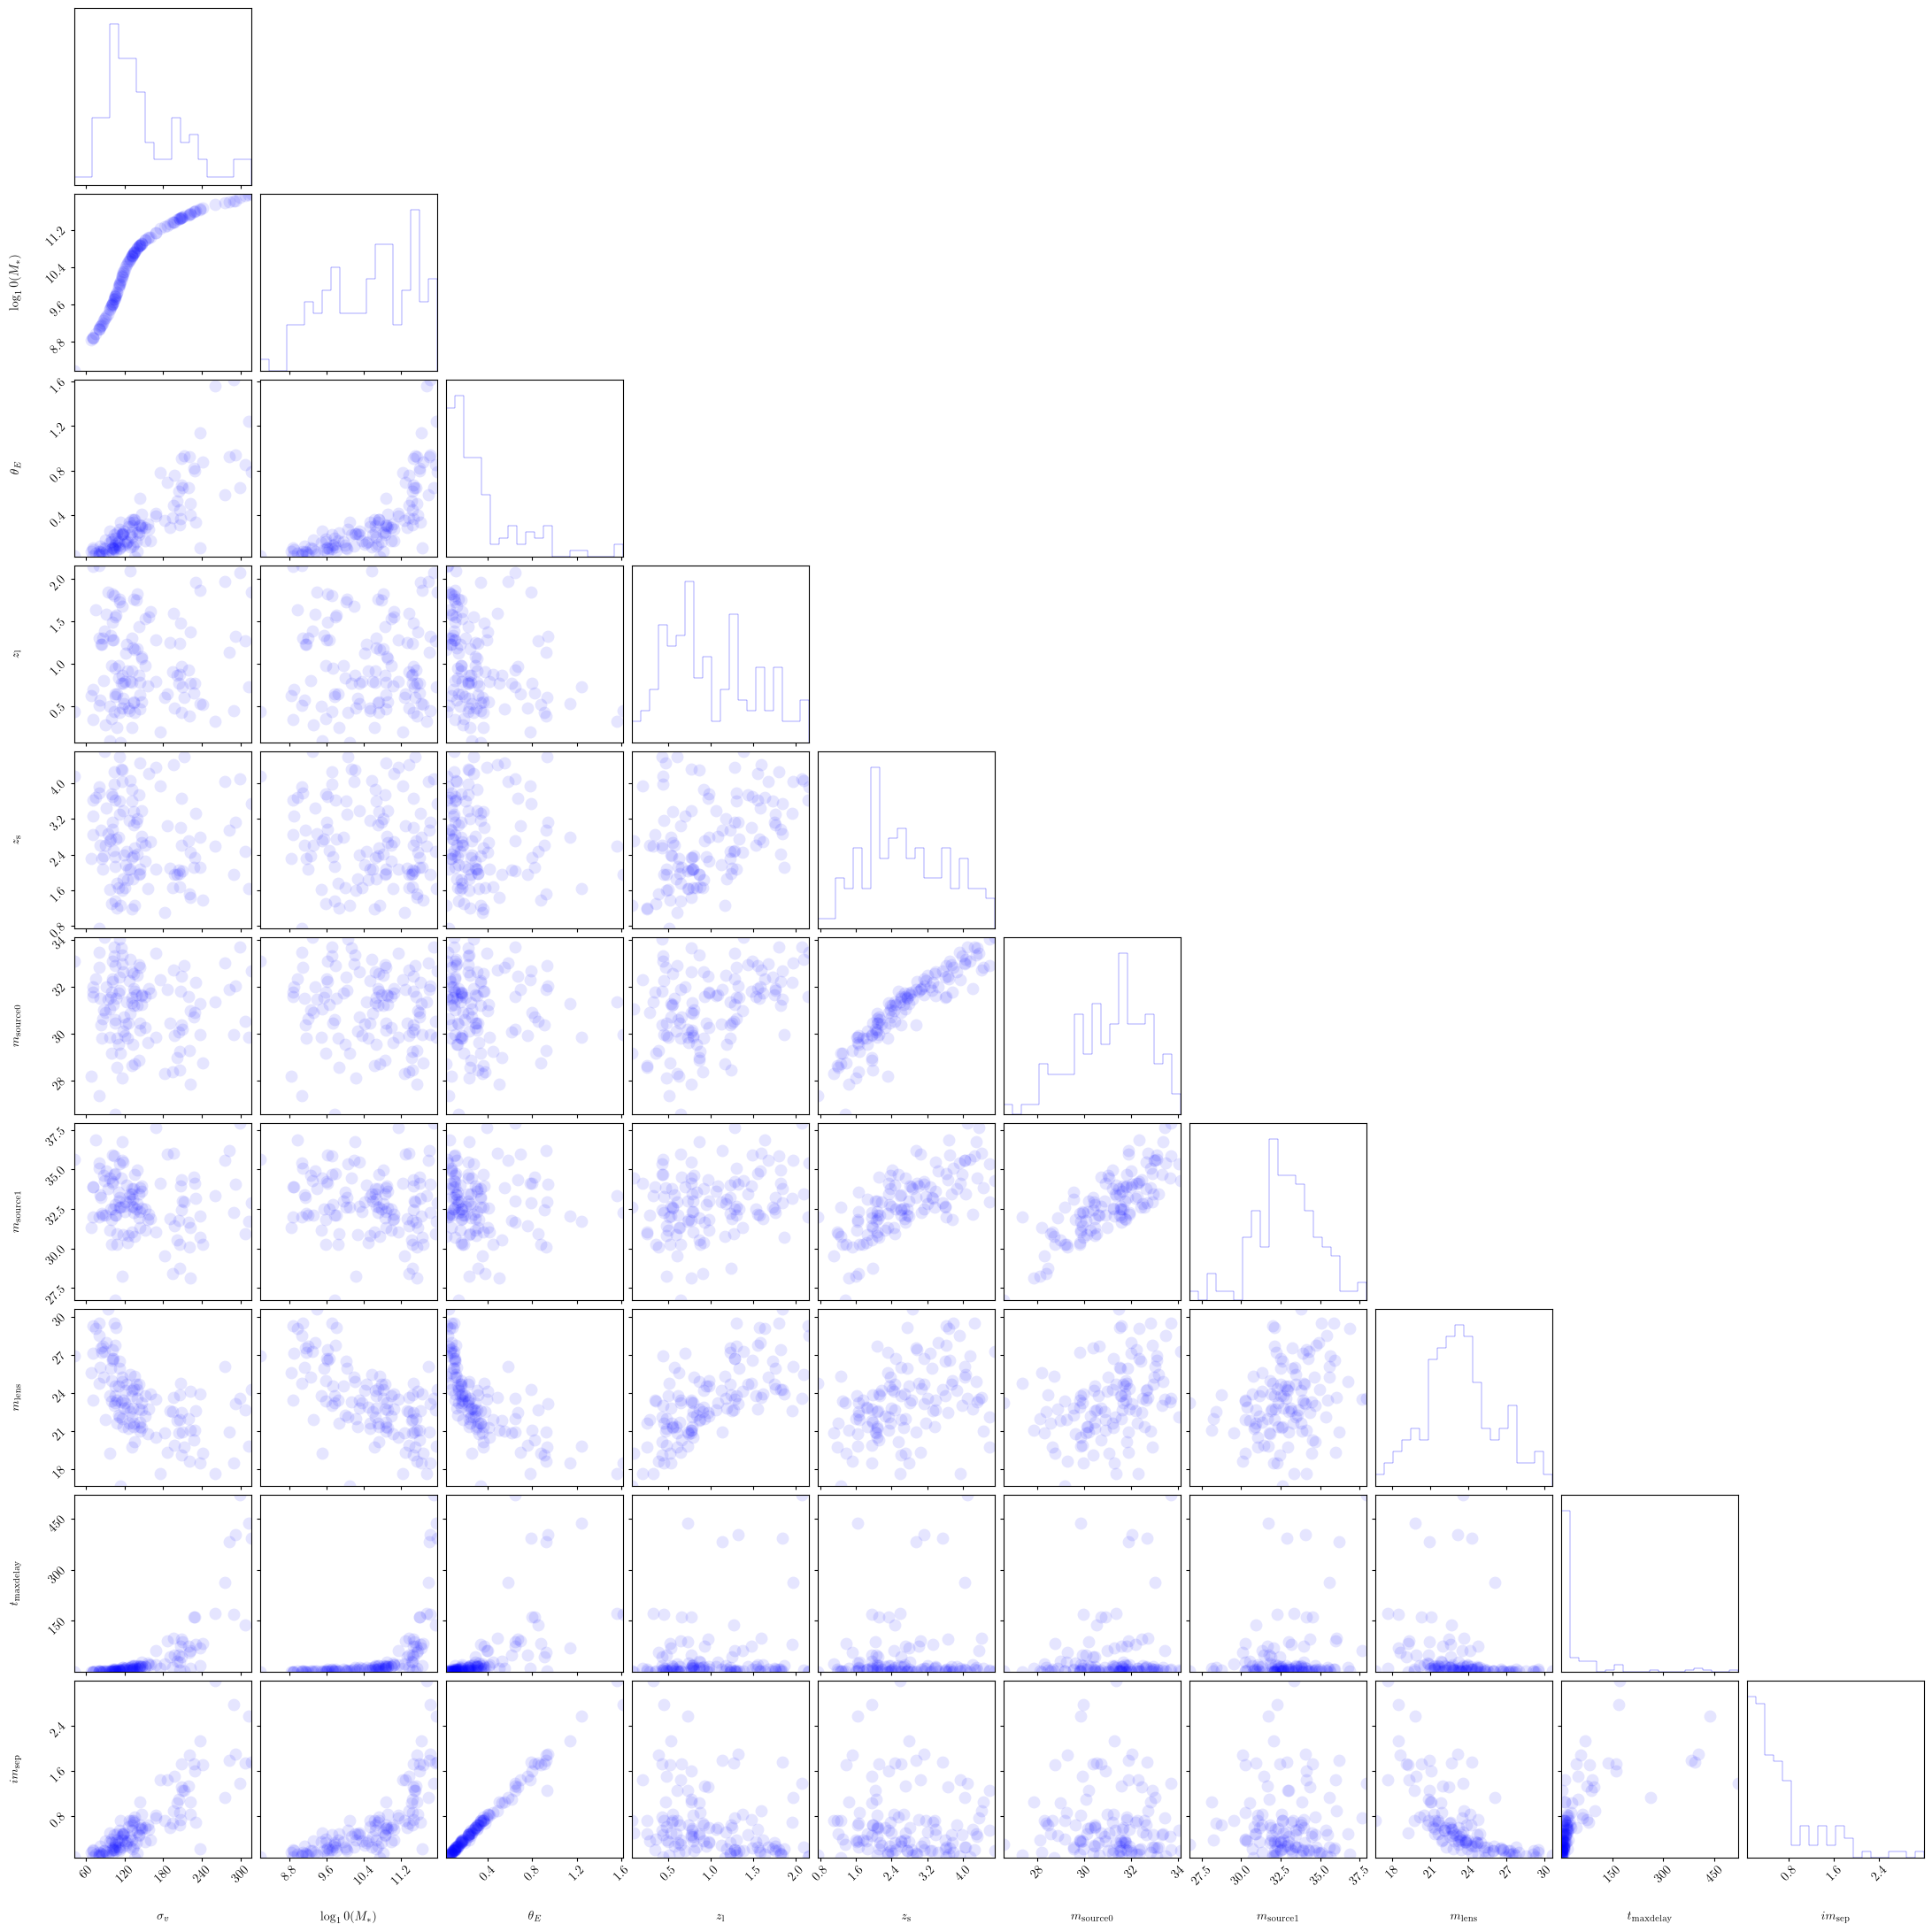

In [24]:
hist2dkwargs = {
    "plot_density": False,
    "plot_contours": False,
    "plot_datapoints": True,
    "color": "b",
    "data_kwargs": {"ms": 10},
}

# Create corner plot with the calculated parameters for the lensed population
corner.corner(np.array(lens_samples), labels=labels, **hist2dkwargs)
plt.show()

In [25]:
# Calculate parameters and apply selection criteria
redshift_dist = []
for ps_lens in bns_lens_population_ps:
    zl = ps_lens.deflector_redshift
    zs = ps_lens.source_redshift_list[0]

    pos_info = ps_lens.point_source_image_positions()
    x_positions = pos_info[0][0]
    y_positions = pos_info[0][1]
    image_sep = np.sqrt(
        (x_positions[0] - x_positions[1]) ** 2 + + (y_positions[0] - y_positions[1]) ** 2
    )

    # image_sep = image_separation_from_positions(ps_lens.point_source_image_positions())
    source_mag = ps_lens.point_source_magnitude(band="i", lensed=True)[0]

    if 0 < zl < zs <= 5:

        # Multiply imaged criteria
        if len(source_mag) > 1:

            # Source magnitude cut
            if np.min(source_mag) < 35:
                if len(source_mag) == 2:
                    flux_ratio = 10 ** ((source_mag[1] - source_mag[0]) / (-2.5))
                    # BNS flux ratio criteria for doubly lensed sources (0.1 < ratio < 10)
                    if flux_ratio > 0.1 and flux_ratio < 10:
                        # Image separation criteria (0.1 < sep < 4)
                        if image_sep > 0.5 and image_sep < 4:
                            redshift_dist.append([zl, zs])
                else:
                    # Image separation criteria (0.1 < sep < 4)
                    if image_sep > 0.5 and image_sep < 4:
                        redshift_dist.append([zl, zs])

        # Magnification criteria
        else:
            if np.min(source_mag) < 25:
                redshift_dist.append([zl, zs])



In [28]:
# Find unlensed BNS distribution as the difference between total BNS and lensed BNS merger event
source_list = list(bns_sample["z"])

lensed_BNS = np.random.choice(
    source_list, 
    size=bns_lens_pop_ps.source_number, 
    replace=True,
)

unlensed_BNS = list(
    (Counter(lensed_BNS) - Counter([sublist[1] for sublist in redshift_dist])).elements()
)

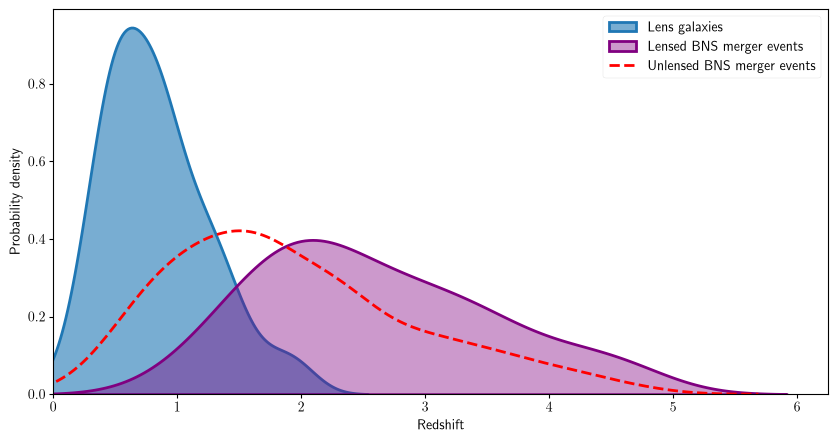

<Figure size 1000x500 with 0 Axes>

In [29]:
# Redshift PDF Plotting
plt.figure(figsize=(10, 5))

# Plot deflector population
sns.kdeplot(
    [sublist[0] for sublist in redshift_dist],
    fill=True,
    label="Lens galaxies",
    alpha=0.6,
    linewidth=2,
)

# Plot source population
sns.kdeplot(
    [sublist[1] for sublist in redshift_dist],
    fill=True,
    label="Lensed BNS merger events",
    color="purple",
    alpha=0.4,
    linewidth=2,
)

# Plot unlensed BNS merger event population
sns.kdeplot(
    unlensed_BNS,
    fill=False,
    linestyle="--",
    label="Unlensed BNS merger events",
    color="red",
    linewidth=2,
    bw_adjust=3,
)

plt.xlabel("Redshift")
plt.ylabel("Probability density")
plt.legend()
plt.grid(False)
plt.xlim(0, None)
plt.figure(figsize=(10, 5))
plt.show()